Simulation ended at t = 120.00 hours (time limit reached)


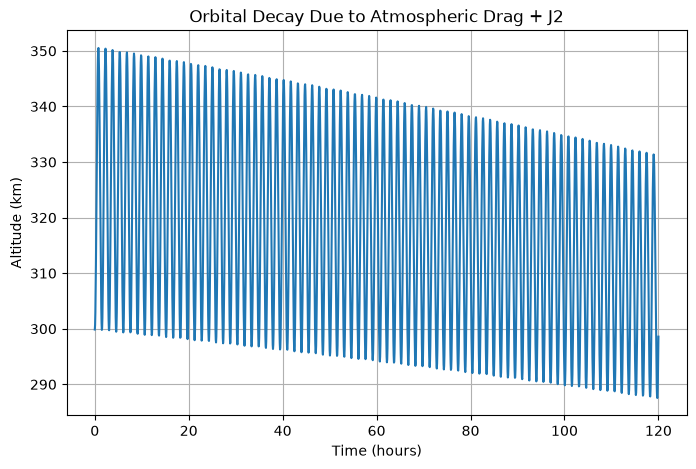

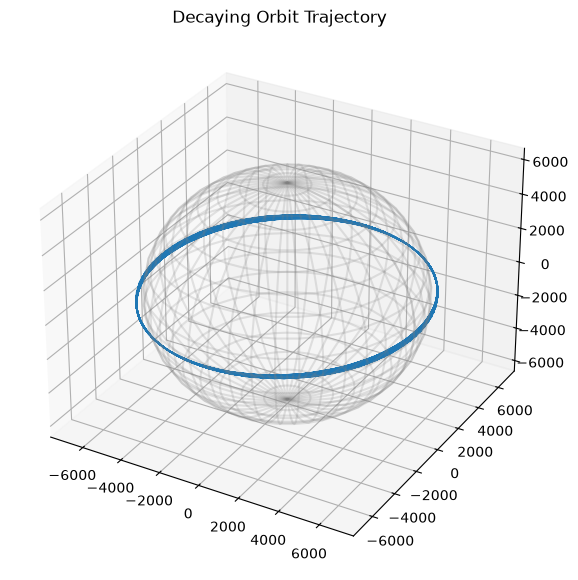

In [5]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# --- Constants ---
mu = 398600.4418      # km^3/s^2
Re = 6378.137          # km
J2 = 1.08263e-3
omega_earth = 7.2921159e-5  # rad/s

# --- Spacecraft properties ---
Cd = 2.2
A = 10e-6               # km^2 (10 m^2)
m = 500.0               # kg

def atmospheric_density(altitude_km):
    table = [
        (0,   1.225,    7.249),   (25,  3.899e-2, 6.349),
        (30,  1.774e-2, 6.682),   (40,  3.972e-3, 7.554),
        (50,  1.057e-3, 8.382),   (60,  3.206e-4, 7.714),
        (70,  8.770e-5, 6.549),   (80,  1.905e-5, 5.799),
        (90,  3.396e-6, 5.382),   (100, 5.297e-7, 5.877),
        (110, 9.661e-8, 7.263),   (120, 2.438e-8, 9.473),
        (130, 8.484e-9, 12.636),  (140, 3.845e-9, 16.149),
        (150, 2.070e-9, 22.523),  (180, 5.464e-10, 29.740),
        (200, 2.789e-10, 37.105), (250, 7.248e-11, 45.546),
        (300, 2.418e-11, 53.628), (350, 9.518e-12, 53.298),
        (400, 3.725e-12, 58.515), (450, 1.585e-12, 60.828),
        (500, 6.967e-13, 63.822), (600, 1.454e-13, 71.835),
        (700, 3.614e-14, 88.667), (800, 1.170e-14, 124.64),
        (900, 5.245e-15, 181.05), (1000, 3.019e-15, 268.00),
    ]
    altitude_km = max(altitude_km, 0)
    if altitude_km >= table[-1][0]:
        h0, rho0, H = table[-1]
    else:
        for i in range(len(table) - 1):
            if table[i][0] <= altitude_km < table[i+1][0]:
                h0, rho0, H = table[i]
                break
    rho_m3 = rho0 * np.exp(-(altitude_km - h0) / H)
    return rho_m3 * 1e9  # kg/km^3

def two_body_j2_drag(t, state):
    r = state[:3]
    v = state[3:]
    rmag = np.linalg.norm(r)
    altitude = rmag - Re

    a_grav = -mu * r / rmag**3

    x, y, z = r
    factor = 1.5 * J2 * mu * Re**2 / rmag**5
    zr2 = 5 * (z**2 / rmag**2)
    a_j2 = factor * np.array([x*(zr2 - 1), y*(zr2 - 1), z*(zr2 - 3)])

    omega_vec = np.array([0, 0, omega_earth])
    v_atm = np.cross(omega_vec, r)
    v_rel = v - v_atm
    v_rel_mag = np.linalg.norm(v_rel)

    if altitude < 1000:
        rho = atmospheric_density(altitude)
        a_drag = -0.5 * rho * v_rel_mag * v_rel * (Cd * A / m)
    else:
        a_drag = np.zeros(3)

    a_total = a_grav + a_j2 + a_drag
    return np.concatenate([v, a_total])

def hit_ground(t, state):
    return np.linalg.norm(state[:3]) - Re - 100
hit_ground.terminal = True
hit_ground.direction = -1

r0 = np.array([6678., 0., 0.])   # ~300 km altitude
v0 = np.array([0., 7.73, 0.5])
state0 = np.concatenate([r0, v0])

t_span = [0, 5 * 24 * 3600]
sol = solve_ivp(two_body_j2_drag, t_span, state0, max_step=30,
                 events=hit_ground, dense_output=True, rtol=1e-8, atol=1e-8)

print(f"Simulation ended at t = {sol.t[-1]/3600:.2f} hours "
      f"({'reentry' if sol.t_events[0].size else 'time limit reached'})")

t_eval = np.linspace(sol.t[0], sol.t[-1], 2000)
traj = sol.sol(t_eval)
altitudes = np.linalg.norm(traj[:3], axis=0) - Re

plt.figure(figsize=(8, 5))
plt.plot(t_eval / 3600, altitudes)
plt.xlabel('Time (hours)'); plt.ylabel('Altitude (km)')
plt.title('Orbital Decay Due to Atmospheric Drag + J2')
plt.grid(True)
plt.show()

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(projection='3d')
ax.plot(traj[0], traj[1], traj[2], linewidth=0.5)
u_, v_ = np.mgrid[0:2*np.pi:40j, 0:np.pi:20j]
ex, ey, ez = Re*np.cos(u_)*np.sin(v_), Re*np.sin(u_)*np.sin(v_), Re*np.cos(v_)
ax.plot_wireframe(ex, ey, ez, color='gray', alpha=0.2)
ax.set_title('Decaying Orbit Trajectory')
plt.show()